In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [19]:
df=pd.read_csv("Mall_Customers.csv")

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [21]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [22]:
num_cols=df.select_dtypes(include='number').columns

In [23]:
preprocessing=ColumnTransformer(
    transformers=[
        ('scaling',StandardScaler(),num_cols),
        ('encoder',OneHotEncoder(handle_unknown='ignore'),['Gender'])
    ],remainder='passthrough'
)

In [24]:
main_pipeline=Pipeline(
    steps=[
        ('preprocessing',preprocessing),
        ('Model',KMeans(n_clusters=2,random_state=42))
    ]
)

In [25]:
main_pipeline.fit(df)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('Model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaling', ...), ('encoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different

In [26]:
# df['result']=main_pipeline.predict(df)
# df['result']

In [27]:
# n_cluster_0=df[df['result']==0]
# n_cluster_1=df[df['result']==1]
# n_cluster_0

In [28]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [29]:
main_pipeline.fit_transform(df)

array([[2.33101815, 3.94965103],
       [2.49306723, 4.05030867],
       [2.73345094, 4.2068501 ],
       [2.233929  , 3.90756149],
       [1.6382302 , 3.66364757],
       [2.23257882, 3.86675955],
       [2.2230715 , 3.97297785],
       [2.56094999, 4.04130246],
       [2.7806892 , 4.50355319],
       [1.76511484, 3.63240088],
       [2.65038365, 4.43379778],
       [2.33582519, 3.96749347],
       [2.14513426, 4.0636658 ],
       [2.06495377, 3.67952372],
       [1.98801938, 3.74673079],
       [2.2597356 , 3.73328071],
       [1.38946615, 3.4313028 ],
       [2.1347821 , 3.60862395],
       [1.62828965, 3.6343176 ],
       [2.2132267 , 3.77177733],
       [1.41823801, 3.32830245],
       [1.92699056, 3.45431806],
       [2.02896815, 3.73747637],
       [1.65838036, 3.34185424],
       [1.8707802 , 3.66612093],
       [1.89466793, 3.37127882],
       [1.15271616, 3.23517128],
       [1.25013044, 3.1129382 ],
       [1.14163742, 3.13647754],
       [2.16598773, 3.44090878],
       [2.

In [30]:
# ELBOW

In [31]:
wcss=[]
for cluster in range(1,10):
    main_pipeline=Pipeline(
        steps=[
            ('preprocessing',preprocessing),
            ('Model',KMeans(n_clusters=cluster,random_state=42))
        ]
    )

    main_pipeline.fit(df)
    wcsss=main_pipeline.named_steps['Model'].inertia_
    wcss.append(wcsss)

print(wcss)

[898.56, 614.0348039103044, 473.69195779575955, 357.54759283135763, 336.62458091003907, 287.6601539596625, 237.4143768084252, 245.3045354050417, 196.8689983473076]


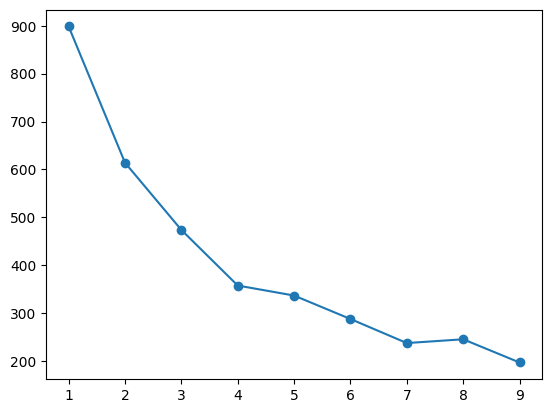

In [32]:
plt.plot(range(1,10),wcss,marker='o')

In [34]:
main_pipeline=Pipeline(
    steps=[
        ('preprocessing',preprocessing),
        ('Model',KMeans(n_clusters=4,random_state=42))
    ]
)

In [35]:
updated_df=main_pipeline.fit_transform(df)

In [36]:
updated_df

array([[3.21886182, 4.27568709, 1.7575346 , 4.3647611 ],
       [3.44696736, 4.78167142, 1.79833626, 4.00593484],
       [3.39368932, 4.17126091, 2.43335054, 4.91769657],
       [3.21584974, 4.62386975, 1.51633981, 3.9128246 ],
       [2.46111243, 3.95842234, 1.47518686, 4.1281412 ],
       [3.22521045, 4.5830325 , 1.47022594, 3.87831861],
       [2.63194938, 3.82784098, 2.42694489, 4.75428951],
       [3.49808869, 4.89679342, 1.86973365, 3.8439672 ],
       [2.38621872, 4.14335874, 3.70041014, 5.29825897],
       [2.7017306 , 4.29110997, 1.3142965 , 3.71628349],
       [2.19916657, 4.17063524, 3.63747031, 5.14815539],
       [3.10028199, 4.81514787, 2.06757643, 3.74087349],
       [1.91548665, 3.86614132, 3.02755718, 4.79863304],
       [3.04929551, 4.41712787, 1.33560742, 3.67702238],
       [2.37356016, 3.63921304, 2.28932398, 4.49517633],
       [3.21656423, 4.47709039, 1.54811992, 3.69807598],
       [2.1097831 , 3.64013794, 1.49966157, 3.98207399],
       [3.11546379, 4.2441091 ,

In [37]:
pca=PCA(n_components=2)

In [38]:
pca_values=pca.fit_transform(updated_df)

In [39]:
df['res']=main_pipeline.predict(df)

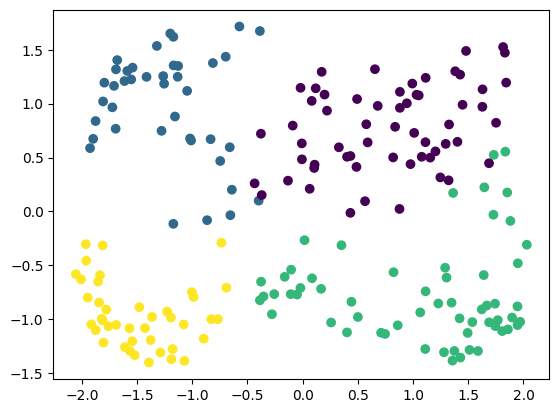

In [40]:
plt.scatter(pca_values[:,0],pca_values[:,1],c=df['res'])

In [41]:
pca=PCA(n_components=0.95)

pca_values=pca.fit_transform(updated_df)
pca_values

array([[ 1.94873225e+00, -4.81442291e-01,  1.57767068e+00,
        -5.11325126e-01],
       [ 1.89693264e+00, -9.84464077e-01,  1.83514006e+00,
        -1.70049961e-01],
       [ 1.85279355e+00,  1.75522606e-01,  2.17904182e+00,
        -5.49795065e-01],
       [ 1.96976752e+00, -1.02392836e+00,  1.44274921e+00,
        -2.45384616e-01],
       [ 2.02994774e+00, -3.08827598e-01,  7.12099644e-01,
        -3.53384315e-01],
       [ 1.94572257e+00, -1.05461278e+00,  1.39630758e+00,
        -2.82746856e-01],
       [ 1.83547799e+00,  5.54280502e-01,  1.45932687e+00,
        -2.98436956e-01],
       [ 1.80645050e+00, -1.11018162e+00,  1.89323749e+00,
        -2.92297136e-02],
       [ 1.81541659e+00,  1.52500365e+00,  2.24661386e+00,
         4.19215353e-01],
       [ 1.94577508e+00, -8.80767690e-01,  7.86165801e-01,
        -1.97165426e-01],
       [ 1.83146629e+00,  1.47227439e+00,  2.04789591e+00,
         5.59565732e-01],
       [ 1.74232685e+00, -8.55646624e-01,  1.64983381e+00,
      

In [42]:
pca.explained_variance_

array([1.63731348, 0.90915881, 0.88267214, 0.27230586])

In [43]:
pca.explained_variance_ratio_

array([0.44234377, 0.24562232, 0.23846657, 0.07356734])